# Baseline Model: Logistic Regression

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from src.data_loader import load_features
from src.preprocessing import clean_data, encode_categoricals
from src.split import patient_split, get_features_and_target

In [2]:
# functions from src/ to load, clean, process, and split data
df = load_features()
df = clean_data(df)

train_df, test_df = patient_split(df)

X_train, y_train, ids_train = get_features_and_target(train_df)
X_test, y_test, ids_test = get_features_and_target(test_df)

X_train, X_test = encode_categoricals(X_train, X_test)

Loaded 101,766 rows, 54 columns.
Unique patients: 71,518

Columns with missing values:
race      2367
gender       3

Readmitted-within-30-days rate: 11.16%

  Dropped 2,423 rows with death/hospice discharge disposition.
  Dropped 3 rows with missing/invalid gender.
  Filled 2,320 missing race values with 'Unknown'.

Raw data: 101,766 encounters; Cleaned data: 99,340 encounters (2,426 dropped total).

Total encounters: 99,340 | Train: 79,462 (80.0%) | Test: 19,878 (20.0%)
Readmit rate - Full: 11.39% | Train: 11.36% | Test: 11.51%

Encoding 33 categorical columns: ['race', 'gender', 'admission_type', 'discharge_disposition', 'admission_source', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide_metformin', 'glipizide_metformin', 'glimepiride_p

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
baseline_model = LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default

In [5]:
# sanity check; get the probabilites of the prediction of the test set
# will be used in evaluating model performance
y_pred_proba = baseline_model.predict_proba(X_test_scaled)
print(y_pred_proba.shape)
y_pred_proba[:5]

(19878, 2)


array([[0.61068813, 0.38931187],
       [0.58477322, 0.41522678],
       [0.6533758 , 0.3466242 ],
       [0.52537155, 0.47462845],
       [0.53515349, 0.46484651]])

### Evaluation of the Baseline Logistic Regression Model

Emphasis of analysis towards precision-recall curve (PR Curve) and area under this curve (pr_auc) due to the class imbalance and since we want to focus on separability of classes rather than basic model performance accuracy. With the pr_auc, the baseline is the percentage of the positive class, which in our case is ~11%. Thus, we are aiming for a pr_auc value >0.11. Recall is another metric to focus on as it determines how well the model can catch the positive class, as well would like to reduce the number of false negatives. 

This model uses the default logistic regression parameters, i.e. L2 and C = 1.0. 

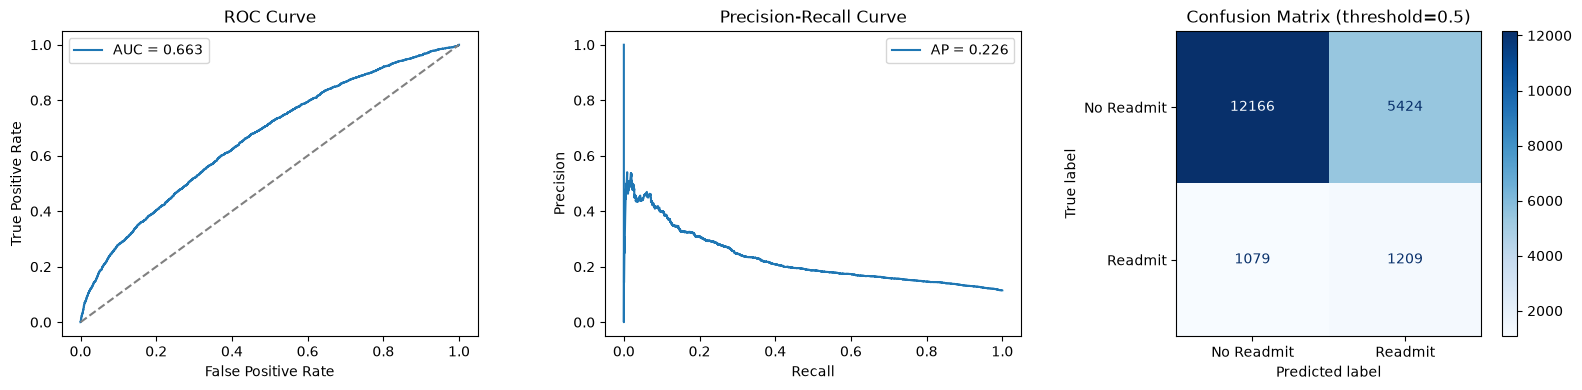

{'roc_auc': 0.6626050541272258,
 'pr_auc': 0.22569608517349884,
 'accuracy': 0.6728544119126673,
 'precision': 0.1822704658525554,
 'recall': 0.5284090909090909,
 'f1': 0.2710458468781527,
 'threshold': 0.5}

In [6]:
from src.evaluate import compute_metrics, evaluate_model

metrics = evaluate_model(y_test, y_pred_proba)
metrics

In [7]:
# compare metrics for train/test set to check for overfitting
y_train_pred_proba = baseline_model.predict_proba(X_train_scaled)

train_metrics = compute_metrics(y_train, y_train_pred_proba)
test_metrics = compute_metrics(y_test, y_pred_proba)

pd.DataFrame([train_metrics, test_metrics], index=["train", "test"])

,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
train,0.669319,0.214068,0.672196,0.183535,0.546865,0.274833,0.5
test,0.662605,0.225696,0.672854,0.182270,0.528409,0.271046,0.5


### Cross Validation and Hyperparameter Tuning

Apply a grid search of 4 C values and either L1 or L2 regularization, thus 8 configurations. 

In [8]:
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold

# parameter grid hyperparameter tuning trying range of C values and testing L1 and L2 regularization
param_grid = {
    'C': [0.001, 0.01, 0.1, 1],
    'l1_ratio': [0, 1],  
    'solver': ['liblinear']  # supports both l1 and l2
}

# cross validation with 5 folds, stratified to maintain class balance, 
cv = StratifiedGroupKFold(n_splits=5)

grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid,
    scoring='average_precision',  # PR-AUC, given class imbalance
    cv=cv,
    n_jobs=-1
)

# grouped by patient to ensure patients remain in the same fold
grid_search.fit(X_train_scaled, y_train, groups=ids_train['patient_nbr'])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'l1_ratio': [0, 1], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro...shuffle=False)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose

In [9]:
print(grid_search.best_params_) # best model configuration
print(grid_search.best_score_)  # mean CV PR-AUC of the winning combination

{'C': 0.01, 'l1_ratio': 1, 'solver': 'liblinear'}
0.21096862713764603


### Evaluate the Best Model

Now that the best model has been determined and tuned, it will be compared to the baseline model. Since the best model configuration uses L1, the coefficients can be analyzed: best performing coeffecients and which coefficients were pushed to zero. 

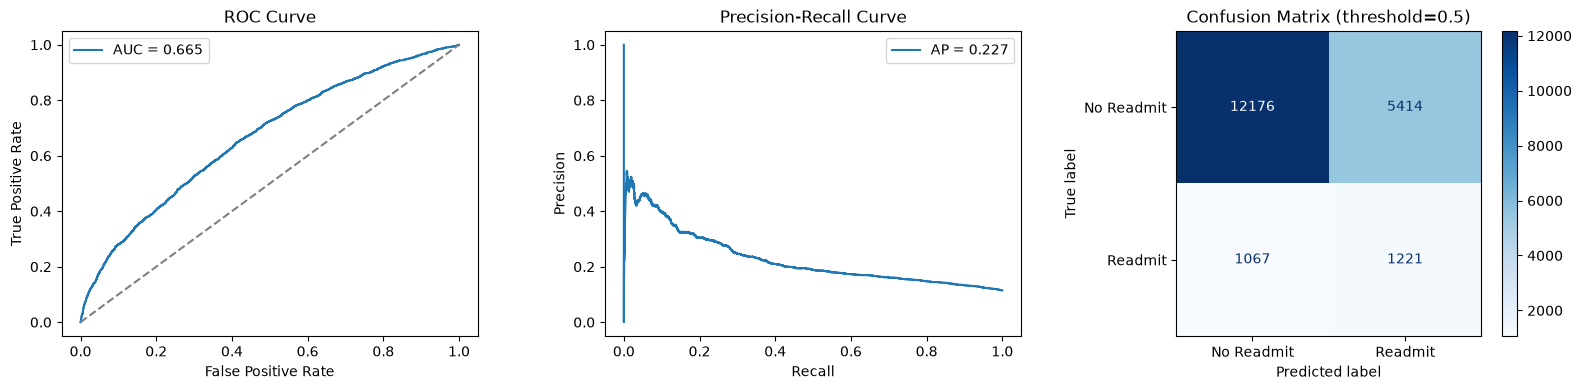

,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
train,0.669697,0.213914,0.674096,0.184760,0.547751,0.276317,0.5
test,0.665223,0.226813,0.673961,0.184024,0.533654,0.273675,0.5


In [10]:
# obtain the best model to be evaluated
best_model = grid_search.best_estimator_

y_train_pred_proba_tuned = best_model.predict_proba(X_train_scaled)
y_test_pred_proba_tuned = best_model.predict_proba(X_test_scaled)

train_metrics_tuned = compute_metrics(y_train, y_train_pred_proba_tuned) # get train metrics to compare with test set
test_metrics_tuned = evaluate_model(y_test, y_test_pred_proba_tuned)  # plots + metrics

pd.DataFrame([train_metrics_tuned, test_metrics_tuned], index=["train", "test"])

In [11]:
# create and output dataframe comparing best model with the baseline model
pd.DataFrame(
    [metrics, test_metrics_tuned],  # `metrics` from original baseline test dict
    index=["baseline (default L2, C=1.0)", "tuned"]
)

,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
"baseline (default L2, C=1.0)",0.662605,0.225696,0.672854,0.182270,0.528409,0.271046,0.5
tuned,0.665223,0.226813,0.673961,0.184024,0.533654,0.273675,0.5


In [12]:
# obtain the top 15 features
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": best_model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

coef_df.head(15)  # strongest predictors, either direction

,feature,coefficient
7,number_inpatient,0.354519
41,discharge_disposition_Discharged/transferred t...,0.150464
35,discharge_disposition_Discharged to home,-0.138637
8,number_diagnoses,0.096603
43,discharge_disposition_Discharged/transferred t...,0.077454
16,has_neoplasms_diagnosis,0.073282
6,number_emergency,0.064726
37,discharge_disposition_Discharged/transferred t...,0.054781
153,diabetesMed_No,-0.052771
164,primary_diagnosis_category_respiratory,-0.049277


In [13]:
zeroed = coef_df[coef_df["coefficient"] == 0]
print(f"{len(zeroed)} of {len(coef_df)} features zeroed out by L1")

57 of 165 features zeroed out by L1


### Threshold Sweep 

The current model have been trained and evaluated on the default threshold of 0.5, which may not be the optimal threshold. A threshold sweep was done to evaluate the performance of the best model at different thresholds

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_scores_lr = best_model.predict_proba(X_test_scaled)[:, 1]

threshold_range = np.arange(0.1, 0.9, 0.05)
sweep_results_lr = []

# Sweep through thresholds and compute metrics (precision, recall, f1, accuracy) for each threshold
for t in threshold_range:
    y_pred_t = (y_scores_lr >= t).astype(int)
    sweep_results_lr.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred_t),
    })

sweep_df_lr = pd.DataFrame(sweep_results_lr)
sweep_df_lr

,threshold,precision,recall,f1,accuracy
0,0.10,0.115114,1.000000,0.206461,0.115203
1,0.15,0.115125,1.000000,0.206480,0.115303
2,0.20,0.115162,0.999563,0.206529,0.115957
3,0.25,0.115276,0.998689,0.206694,0.117617
4,0.30,0.117531,0.990385,0.210126,0.142972
5,0.35,0.127168,0.942308,0.224093,0.248918
6,0.40,0.144013,0.832605,0.245553,0.411108
7,0.45,0.163180,0.681818,0.263336,0.560922
8,0.50,0.184024,0.533654,0.273675,0.673961
9,0.55,0.208399,0.405594,0.275330,0.754251


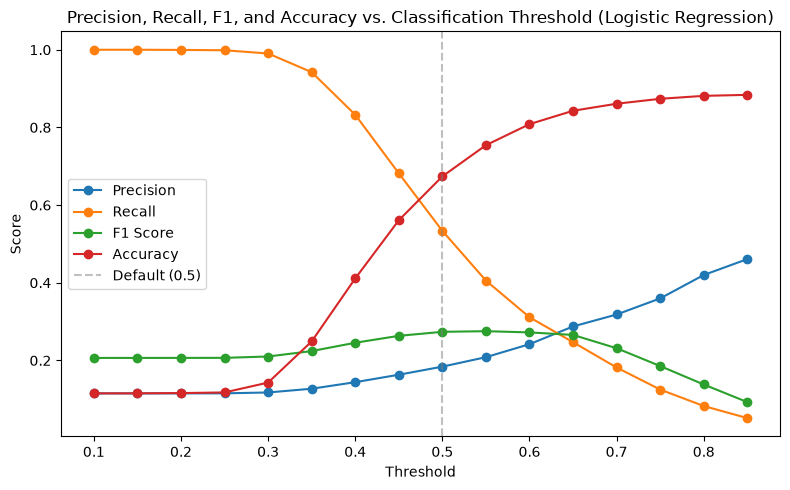

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(sweep_df_lr["threshold"], sweep_df_lr["precision"], label="Precision", marker='o')
plt.plot(sweep_df_lr["threshold"], sweep_df_lr["recall"], label="Recall", marker='o')
plt.plot(sweep_df_lr["threshold"], sweep_df_lr["f1"], label="F1 Score", marker='o')
plt.plot(sweep_df_lr["threshold"], sweep_df_lr["accuracy"], label="Accuracy", marker='o')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label="Default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1, and Accuracy vs. Classification Threshold (Logistic Regression)")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold Sweep Results

Precision and recall trade off steeply through the 0.3-0.5 threshold range. Recall falls from 0.99 at threshold=0.30 to 0.53 at threshold=0.50. F1 peaks at threshold=0.55 (F1=0.275), only marginally above the default 0.50 (F1=0.274). Given the HRRP framing prioritizes recall, and the curve's steepness means large recall gains are available just below the default threshold, operating around threshold ~0.40-0.45 would be ideal. For instance, threshold=0.45 achieves recall of 0.68 at a precision cost of 0.163, a substantial recall gain for a modest threshold decrease.

## Key Takeaways 

Baseline model and tuned model had comparable performances:
- Both models yielding an roc_auc value of ~0.66 and pr_auc value of ~0.22.
- Both models exceed the random baseline (ROC-AUC of 0.5; PR-AUC ≈ positive class rate of ~0.11).
- Train and test performance in both models were similar indicating the models are not overfitting and generalizes well to unseen patients. 

The best model configuration utilized L1 regularization
- drops 57 out of 165 features (~34.5%). 
- The strongest coefficient was number of inpatient visits in the past year
    - This agrees with the previous finding from the EDA notebook which determined inpatient visits as a strong indicator of early readmission. 
    - However, feature coefficients are taken within the context of other features and their combined effects. 

At the default 0.5 threshold, models favors recall over precision: 
- recall ~ 0.53 - catches about half of true early readmission.
- precision ~ 0.18 - of all positive class predictions ~18% were actually readmitted.
- likely caused by balancing class_weights, which penalizes missing the minority-class more heavily yielding more false positive.
- in a clinical setting, increased false positives may be preferable to increased false negatives. 

Recommended operating threshold: 
- ~0.40–0.45, prioritizing recall given the HRRP framing